# Transmission Matrix Retrieval via Gerchberg–Saxton
**Setup:** Ajile DMD 4500 (USB3) + Alkeria CELERA camera  
**Method:** Random binary macropixel probing → TM retrieval (GS alternating projections)  
then GS binary DMD optimisation to focus light onto a target camera region.

### DMD binary macropixel constraint
All DMD patterns are binary: each macro-region (block of DMD pixels) is either **fully ON (255)** or **fully OFF (0)**.  
This matches the physical constraint that a DMD mirror can only be tilted to two discrete angles.

### Workflow
1. Init DMD (USB3) & camera
2. Capture reference frame — determine camera resolution
3. Set up DMD and camera macro-region grids
4. Send K random **binary macropixel** probe patterns → capture camera response
5. Retrieve TM via GS alternating projections (both complex and intensity-only variants)
6. Validate TM with a correlation check on fresh probes
7. Run GS on the TM to find the **binary** DMD pattern that focuses onto a target region
8. Display result and compute enhancement factor

## 1. Imports

In [2]:
import sys, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from tqdm.auto import tqdm

import alkusb3
from alkusb3 import celera_camera, feature, trigger_source

import ajiledriver as aj

print("alkusb3 version:", alkusb3.__version__ if hasattr(alkusb3, '__version__') else 'loaded')
print("ajiledriver loaded")

alkusb3 version: loaded
ajiledriver loaded


c:\Users\USER\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. DMD Controller + Project Builder

In [3]:
class AjileController:
    def __init__(self, ip="192.168.200.1", port=5005, project_name="Project"):
        self.ip_address     = ip
        self.netmask        = "255.255.255.0"
        self.gateway        = "0.0.0.0"
        self.port           = port
        self.comm_interface = aj.USB3_INTERFACE_TYPE
        self.device_number  = 0
        self.project_name   = project_name
        self.repeat_count   = 0    # 0 = loop indefinitely
        self.frame_time_ms  = 150
        self.sequence_id    = 1
        self.system         = None

    def connect(self):
        self.system = aj.HostSystem()
        self.system.SetConnectionSettingsStr(
            self.ip_address, self.netmask, self.gateway, self.port)
        self.system.SetCommunicationInterface(self.comm_interface)
        self.system.SetUSB3DeviceNumber(self.device_number)
        if self.system.StartSystem() != aj.ERROR_NONE:
            print(f"CRITICAL: Failed to connect to Ajile device at {self.ip_address}")
            sys.exit(-1)
        print(f"Connected to Ajile device: {self.ip_address}")

    def start(self, create_project_fn, image_array, quiet=False):
        """Load project and start DMD sequence (non-blocking once running)."""
        project = create_project_fn(
            sequenceID          = self.sequence_id,
            sequenceRepeatCount = self.repeat_count,
            frameTime_ms        = self.frame_time_ms,
            components          = self.system.GetProject().Components(),
            projectname         = self.project_name,
            image_ar            = image_array,
        )
        _, found = project.FindSequence(self.sequence_id)
        if not found:
            sys.exit(-1)

        comp_idx = self.system.GetProject().GetComponentIndexWithDeviceType(
            aj.DMD_4500_DEVICE_TYPE)
        driver = self.system.GetDriver()

        driver.StopSequence(comp_idx)
        driver.LoadProject(project)
        driver.WaitForLoadComplete(-1)

        for _, sequence in project.Sequences().iteritems():
            roi_w = sequence.SequenceItems()[0].Frames()[0].RoiWidthColumns()
            if 0 < roi_w < aj.DMD_3000_IMAGE_WIDTH_MAX:
                driver.SetLiteMode(True, comp_idx)
            driver.StartSequence(sequence.ID(), comp_idx)
            while self.system.GetDeviceState(comp_idx).RunState() != aj.RUN_STATE_RUNNING:
                time.sleep(0.005)

        if not quiet:
            print("DMD sequence running.")

    def stop(self):
        if self.system:
            comp_idx = self.system.GetProject().GetComponentIndexWithDeviceType(
                aj.DMD_4500_DEVICE_TYPE)
            self.system.GetDriver().StopSequence(comp_idx)
            print("DMD sequence stopped.")


def create_project(sequenceID=1, sequenceRepeatCount=0, frameTime_ms=150,
                   components=None, projectname="project", image_ar=None):
    if image_ar is None or len(image_ar) == 0:
        print("No image array provided."); sys.exit(-1)

    project = aj.Project(projectname)
    if components is not None:
        project.SetComponents(components)

    if len(project.Components()) == 0:
        print("No connected devices detected."); sys.exit(-1)

    controller_idx, dmd_idx = None, None
    for i, comp in enumerate(project.Components()):
        hw = comp.DeviceType().HardwareType()
        if hw in {aj.AJILE_CONTROLLER_DEVICE_TYPE,
                  aj.AJILE_2PORT_CONTROLLER_DEVICE_TYPE,
                  aj.AJILE_3PORT_CONTROLLER_DEVICE_TYPE}:
            controller_idx = i
        elif hw == aj.DMD_4500_DEVICE_TYPE:
            dmd_idx = i

    if controller_idx is None or dmd_idx is None:
        print("Controller or DMD component not found."); sys.exit(-1)

    in_trig  = project.Components()[controller_idx].InputTriggerSettings()
    out_trig = project.Components()[controller_idx].OutputTriggerSettings()
    for i in range(len(out_trig)):
        out_trig[i] = aj.ExternalTriggerSetting(aj.RISING_EDGE, 0)
    project.SetTriggerSettings(controller_idx, in_trig, out_trig)

    rule = aj.TriggerRule()
    rule.AddTriggerFromDevice(aj.TriggerRulePair(dmd_idx, aj.FRAME_STARTED))
    rule.SetTriggerToDevice(aj.TriggerRulePair(controller_idx, aj.EXT_TRIGGER_OUTPUT_1))
    project.AddTriggerRule(rule)

    for idx, img in enumerate(image_ar, start=1):
        image = aj.Image(idx)
        image.ReadFromMemory(img, 8, aj.ROW_MAJOR_ORDER, aj.DMD_4500_DEVICE_TYPE)
        project.AddImage(image)

    sequence = aj.Sequence(sequenceID, projectname, aj.DMD_4500_DEVICE_TYPE,
                           aj.SEQ_TYPE_PRELOAD, sequenceRepeatCount)
    project.AddSequence(sequence)
    project.AddSequenceItem(aj.SequenceItem(sequenceID, 1))

    for i in range(len(image_ar)):
        frame = aj.Frame()
        frame.SetSequenceID(sequenceID)
        frame.SetImageID(i + 1)
        frame.SetFrameTimeMSec(frameTime_ms)
        project.AddFrame(frame)

    return project

## 3. Camera Controller (Alkeria CELERA via alkusb3)

In [4]:
class CameraController:
    def __init__(self, camera_index=0):
        self.camera_index = camera_index
        self._cam = None

    def connect(self):
        self._cam = celera_camera()
        ids = self._cam.get_camera_list()
        if not ids:
            raise RuntimeError("No CELERA cameras detected.")
        self._cam.camera = self.camera_index
        self._cam.init()
        print(f"Connected to camera [{self.camera_index}]: {ids[self.camera_index]}")

    def set_exposure(self, shutter_value):
        self._cam.set_feature_value(feature.shutter, shutter_value)

    def set_gain(self, gain_value):
        self._cam.set_feature_value(feature.gain, gain_value)

    def set_roi(self, width, height, start_x=0, start_y=0):
        self._cam.image_size_x  = width
        self._cam.image_size_y  = height
        self._cam.image_start_x = start_x
        self._cam.image_start_y = start_y

    def start(self):
        self._cam.acquire = True

    def capture_frame(self):
        """Capture one frame; returns numpy array."""
        buf = self._cam.get_image_ptr(sync=True)
        if buf is None:
            raise RuntimeError("Frame capture timed out.")
        arr = buf.as_numpy_array(copy=True)
        buf.dispose()
        return arr

    def disconnect(self):
        if self._cam:
            self._cam.acquire = False
            self._cam.close()
            self._cam = None
            print("Camera disconnected.")

## 4. Pattern Generation & Core Helpers

**Binary macropixel rule**: Every DMD pattern is `uint8` with values **0 (OFF) or 255 (ON)** only.  
Each macropixel covers a rectangular block of physical DMD pixels — all mirrors in a block move together.

In [21]:
# ── DMD constants ─────────────────────────────────────────────
DMD_WIDTH  = aj.DMD_IMAGE_WIDTH_MAX   # 912
DMD_HEIGHT = aj.DMD_IMAGE_HEIGHT_MAX  # 1140


def dmd_chessboard(width, height, sq_width, sq_height, sub_sq):
    """Binary checkerboard pattern confined to a central sub_sq×sub_sq region."""
    board = np.zeros((height, width), dtype=np.uint8)
    cx, cy = width // 2, height // 2
    x0, y0 = cx - sub_sq // 2, cy - sub_sq // 2
    x1, y1 = cx + sub_sq // 2, cy + sub_sq // 2
    for y in range(y0, y1, sq_height * 2):
        for x in range(x0, x1, sq_width * 2):
            cv2.rectangle(board, (x, y), (x + sq_width, y + sq_height), 255, -1)
            if x + sq_width < x1 and y + sq_height < y1:
                cv2.rectangle(board,
                              (x + sq_width, y + sq_height),
                              (x + 2 * sq_width, y + 2 * sq_height), 255, -1)
    return board.reshape(1, height, width, 1)


def dmd_vec_to_pattern(vec, dmd_grid, dmd_w=None, dmd_h=None):
    """
    Convert an N-element binary vector (values 0 or 1) to a uint8 DMD pattern
    with values 0 (OFF) or 255 (ON).  Each element controls one macropixel block.

    This enforces the physical binary constraint of the DMD:
    every mirror in a block is tilted identically.
    """
    if dmd_w is None: dmd_w = DMD_WIDTH
    if dmd_h is None: dmd_h = DMD_HEIGHT
    rows, cols = dmd_grid
    rh, rw = dmd_h // rows, dmd_w // cols
    pattern = np.zeros((DMD_HEIGHT, DMD_WIDTH), dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            if vec[i * cols + j]:          # any nonzero → ON
                pattern[DMD_HEIGHT//2 - dmd_h + i*rh:DMD_HEIGHT//2 - dmd_h + (i+1)*rh, DMD_WIDTH//2 - dmd_w + j*rw:DMD_WIDTH//2 - dmd_w + (j+1)*rw] = 255
    return pattern   # uint8, values 0 or 255 only


def send_pattern_to_dmd(dmd_ctrl, pattern_2d, frame_time_ms=150, quiet=False):
    """
    Display a single binary macropixel pattern on the DMD.
    pattern_2d must be uint8 with values 0 or 255.
    The pattern loops continuously until the next call replaces it.
    """
    unique_vals = set(np.unique(pattern_2d).tolist())
    assert unique_vals.issubset({0, 255}), (
        f"DMD pattern must be binary (0/255), got values: {unique_vals}")
    pattern_4d = pattern_2d[np.newaxis, :, :, np.newaxis]  # (1, H, W, 1)
    dmd_ctrl.frame_time_ms = frame_time_ms
    dmd_ctrl.repeat_count  = 0   # loop indefinitely; next start() call stops it
    dmd_ctrl.start(create_project, pattern_4d, quiet=quiet)


def capture_image(cam_ctrl):
    """Capture one frame from the CELERA camera. Returns float32 2-D array."""
    arr = cam_ctrl.capture_frame()
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return arr.astype(np.float32)


def cam_image_to_vec(image, cam_grid, origin_x, origin_y, region_w, region_h):
    """Average pixels inside each camera macro-region → N-element float32 vector."""
    if image.ndim == 3:
        image = image.mean(axis=2)
    rows, cols = cam_grid
    vec = np.empty(rows * cols, dtype=np.float32)
    for i in range(rows):
        for j in range(cols):
            y = origin_y + i * region_h
            x = origin_x + j * region_w
            vec[i * cols + j] = image[y:y+region_h, x:x+region_w].mean()
    return vec

## 5. Connect DMD & Camera

In [18]:
# ── DMD ───────────────────────────────────────────────────────
dmd = AjileController(ip="192.168.200.1", port=5005, project_name="TM_Experiment")
dmd.connect()
print(f"DMD size: {DMD_WIDTH} × {DMD_HEIGHT} px")

Connected to Ajile device: 192.168.200.1
DMD size: 912 × 1140 px


In [7]:
cam = CameraController(camera_index=0)
cam.connect()
cam.set_exposure(9000) #7000
cam.start()
print("Camera grabbing started")

Connected to camera [0]: CELERA1 CO5S-C s/n A5C627F2
Camera grabbing started


## 6. Reference Capture — Determine Camera Resolution & Test Pattern

In [8]:
# Send all-ON to illuminate the FOV; capture one frame to determine camera resolution
_all_on = np.full((DMD_HEIGHT, DMD_WIDTH), 255, dtype=np.uint8)
send_pattern_to_dmd(dmd, _all_on, frame_time_ms=300)
time.sleep(0.1)
_ref = capture_image(cam)
CAM_H, CAM_W = _ref.shape[:2]
print(f"Camera: {CAM_W} × {CAM_H} px  dtype={_ref.dtype}")

DMD sequence running.
Camera: 2456 × 2050 px  dtype=float32


## 7. Define Macro-Region Grids

Both the DMD and camera are divided into **N macro-regions** arranged in a grid.  
- **DMD macropixels**: each region is a block of `(DMD_HEIGHT/rows) × (DMD_WIDTH/cols)` mirrors — all either ON or OFF.
- **Camera regions**: each region averages the intensity over a rectangular block of sensor pixels.

Adjust `CAM_ORIGIN_X/Y` and `CAM_SIZE_X/Y` until the cyan grid covers the illuminated spot.

In [9]:
# ── DMD macropixel grid ───────────────────────────────────────
DMD_GRID = (4, 4) 
N_BLOCKS = DMD_GRID[0] * DMD_GRID[1]

dmd_bw = DMD_WIDTH  // DMD_GRID[1]
dmd_bh = DMD_HEIGHT // DMD_GRID[0]
print(f"DMD: {DMD_GRID[0]}×{DMD_GRID[1]} macropixels, each {dmd_bw}×{dmd_bh} px → {N_BLOCKS} input modes")

# ── Camera region grid ────────────────────────────────────────
# Set region size in pixels first; total ROI = grid × region size.
# Adjust CAM_ORIGIN_X/Y to centre the ROI on the illuminated spot.
CAM_REGION_W = 4        # px per region (width)  — try 2 or 4
CAM_REGION_H = 4        # px per region (height) — try 2 or 4
CAM_GRID     = (4, 4)   # grid of regions (rows × cols)

CAM_SIZE_X   = CAM_GRID[1] * CAM_REGION_W   # total ROI width
CAM_SIZE_Y   = CAM_GRID[0] * CAM_REGION_H   # total ROI height
CAM_ORIGIN_X = (CAM_W - CAM_SIZE_X) // 2    # centred by default — adjust as needed
CAM_ORIGIN_Y = (CAM_H - CAM_SIZE_Y) // 2
N_MODES_OUT  = CAM_GRID[0] * CAM_GRID[1]

assert CAM_ORIGIN_X >= 0 and CAM_ORIGIN_Y >= 0, "ROI origin is out of frame"
print(f"Cam: {CAM_GRID[0]}×{CAM_GRID[1]} regions, each {CAM_REGION_W}×{CAM_REGION_H} px "
      f"→ {N_MODES_OUT} output modes")
print(f"ROI : ({CAM_ORIGIN_X}, {CAM_ORIGIN_Y}) + {CAM_SIZE_X}×{CAM_SIZE_Y} px")

DMD: 4×4 macropixels, each 228×285 px → 16 input modes
Cam: 4×4 regions, each 4×4 px → 16 output modes
ROI : (1220, 1017) + 16×16 px


DMD sequence running.


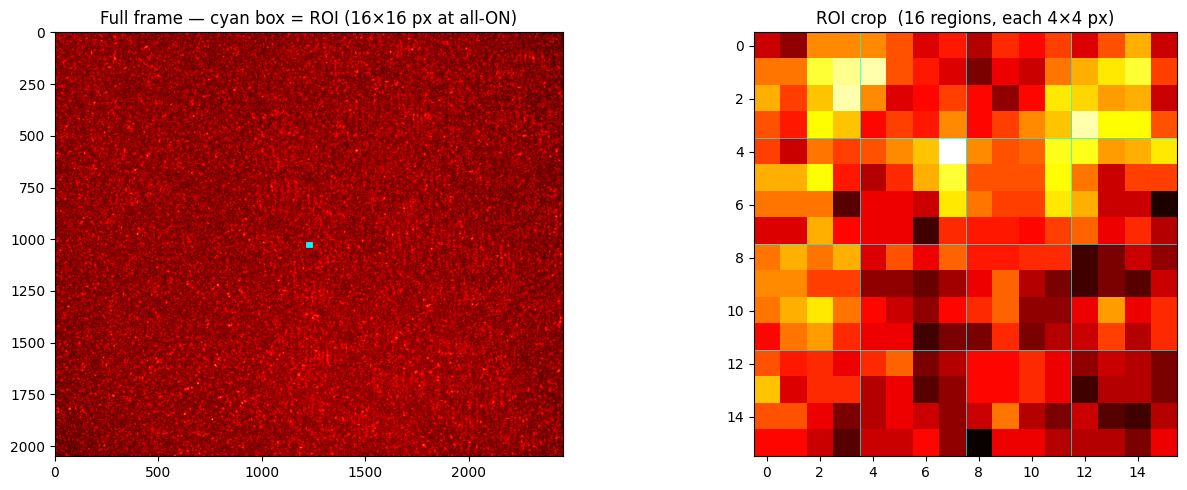

ROI mean intensity : 30.8


In [10]:
# ── Preview ROI on reference frame ───────────────────────────
# Shows where the camera grid sits. Move CAM_ORIGIN_X/Y in cell08 until
# the cyan box lands on the brightest / most-active part of the image.
send_pattern_to_dmd(dmd, _all_on, frame_time_ms=300)
time.sleep(0.1)
_ref = capture_image(cam)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(_ref, cmap='hot')
axes[0].add_patch(mpatches.Rectangle(
    (CAM_ORIGIN_X, CAM_ORIGIN_Y), CAM_SIZE_X, CAM_SIZE_Y,
    lw=2, edgecolor='cyan', facecolor='none'))
axes[0].set_title(f"Full frame — cyan box = ROI ({CAM_SIZE_X}×{CAM_SIZE_Y} px at all-ON)")

roi_crop = _ref[CAM_ORIGIN_Y:CAM_ORIGIN_Y+CAM_SIZE_Y,
                CAM_ORIGIN_X:CAM_ORIGIN_X+CAM_SIZE_X]
axes[1].imshow(roi_crop, cmap='hot', interpolation='nearest')
for i in range(CAM_GRID[0] + 1):
    axes[1].axhline(i * CAM_REGION_H - 0.5, color='cyan', lw=0.5)
for j in range(CAM_GRID[1] + 1):
    axes[1].axvline(j * CAM_REGION_W - 0.5, color='cyan', lw=0.5)
axes[1].set_title(f"ROI crop  ({N_MODES_OUT} regions, each {CAM_REGION_W}×{CAM_REGION_H} px)")
plt.tight_layout(); plt.show()

roi_mean = float(roi_crop.mean())
print(f"ROI mean intensity : {roi_mean:.1f}")
if roi_mean < 5:
    print("  ⚠  Very low signal — adjust CAM_ORIGIN_X/Y in the cell above to cover the illuminated spot.")

## 8. Preview DMD Macropixel Layout

In [54]:
# ── Tunable parameters ────────────────────────────────────────
N_PATTERNS     = 2 * N_BLOCKS  # K probe patterns (7N recommended; 4N minimum)
PROBE_FRAME_MS = 150            # DMD display time per pattern (ms)
SETTLE_S       = 0.05           # settle delay before capture (s)
N_AVG          = 3              # frames averaged per pattern (reduces noise by √N_AVG)

# ── Dark frame (all DMD mirrors OFF) ─────────────────────────
_all_off = np.zeros((DMD_HEIGHT , DMD_WIDTH), dtype=np.uint8)
send_pattern_to_dmd(dmd, _all_off, frame_time_ms=300)
time.sleep(0.1)
_dark = np.mean([capture_image(cam) for _ in range(N_AVG)], axis=0)  # (H, W) float32
print(f"Dark frame — mean: {_dark.mean():.2f}  max: {_dark.max():.2f}")

# ── Random binary probe patterns ──────────────────────────────
X = np.random.randint(0, 2, (N_PATTERNS, N_BLOCKS), dtype=np.uint8)

# Y computed on-the-fly as region averages (avoids storing N×H×W in RAM)
Y        = np.empty((N_PATTERNS, N_MODES_OUT), dtype=np.float32)
_samples = {}   # store a few raw frames for the display cell below

print(f"Collecting {N_PATTERNS} patterns  (K/N={N_PATTERNS/N_BLOCKS:.0f}×,  {N_AVG} frames/pattern) ...")
for k in range(N_PATTERNS):
    pat = dmd_vec_to_pattern(X[k], DMD_GRID, 800, 800)
    # plt.imshow(pat)
    # plt.show()
    # break
    send_pattern_to_dmd(dmd, pat, frame_time_ms=PROBE_FRAME_MS, quiet=True)
    time.sleep(SETTLE_S)

    # Average N_AVG frames then subtract dark
    frames  = np.mean([capture_image(cam) for _ in range(N_AVG)], axis=0)
    img_sub = np.clip(frames - _dark, 0, None)              # dark-subtracted float32

    Y[k] = cam_image_to_vec(img_sub, CAM_GRID,
                             CAM_ORIGIN_X, CAM_ORIGIN_Y, CAM_REGION_W, CAM_REGION_H)

    if k < 4:                                               # save a few for display
        _samples[k] = img_sub

    bar = '█' * int(30*(k+1)/N_PATTERNS) + '░'*(30 - int(30*(k+1)/N_PATTERNS))
    print(f"\r  [{bar}] {k+1}/{N_PATTERNS}", end='', flush=True)

print()
print(f"X : {X.shape}  binary vectors  (0/1)")
print(f"Y : {Y.shape}  float32  mean={Y.mean():.2f}  max={Y.max():.2f}")
if Y.mean() < 1:
    print("  ⚠  Signal very low — check ROI alignment and shutter.")

DMD sequence running.
Dark frame — mean: 87.55  max: 241.67
  [██████████████████████████████] 32/32
X : (32, 16)  binary vectors  (0/1)
Y : (32, 16)  float32  mean=7.40  max=45.17


## 9. Collect Probe Measurements

Each probe pattern is a **random binary vector** of length N (0 = macropixel OFF, 1 = macropixel ON).  
`dmd_vec_to_pattern` expands it to a full `uint8` DMD image with values 0 or 255.

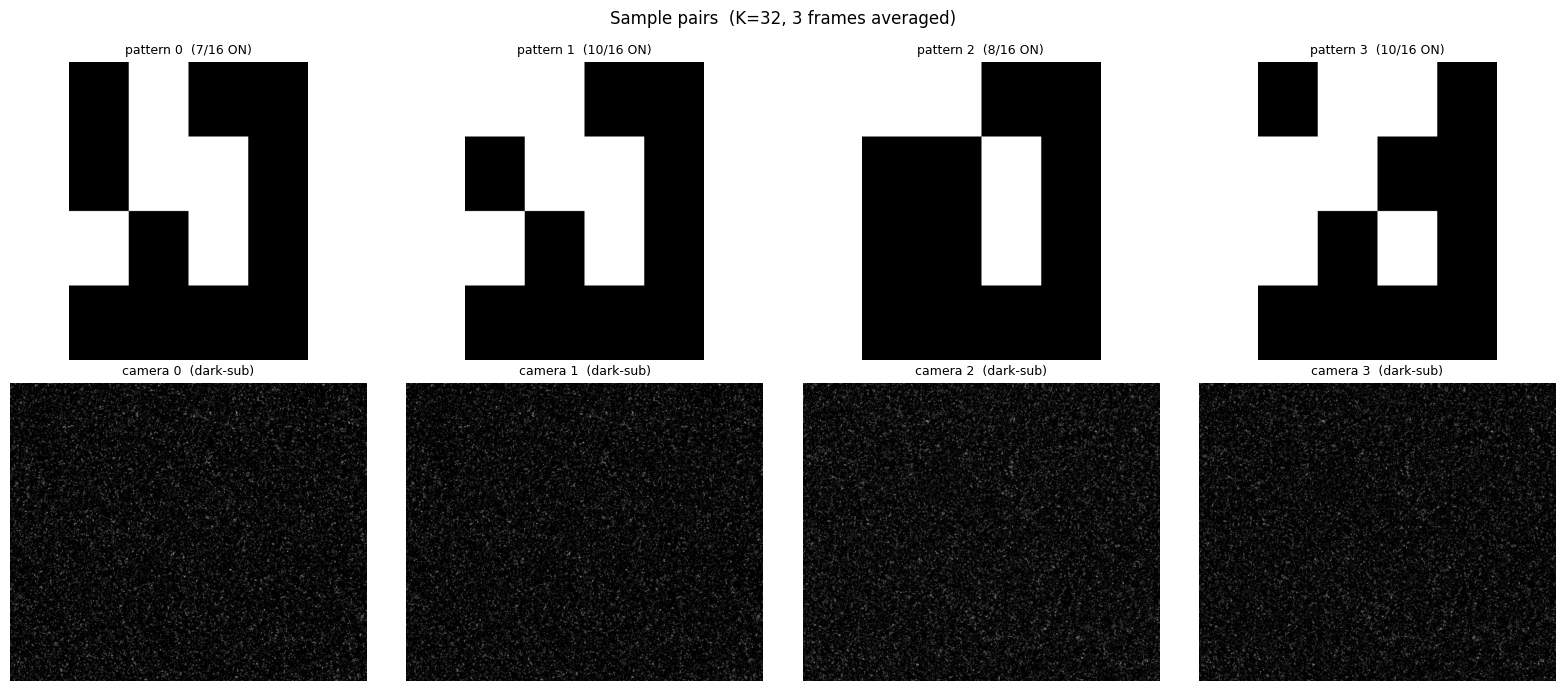

Estimated speckle grain radius ≈ 2 px  (current CAM_REGION = 4×4 px)


In [55]:
# ── Sample input/output pairs ─────────────────────────────────
N_SHOW = min(4, len(_samples))
fig, axes = plt.subplots(2, N_SHOW, figsize=(4*N_SHOW, 7))
for col, k in enumerate(list(_samples)[:N_SHOW]):
    pat = dmd_vec_to_pattern(X[k], DMD_GRID)
    axes[0, col].imshow(pat, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(f"pattern {k}  ({X[k].sum()}/{N_BLOCKS} ON)", fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(_samples[k], cmap='gray')
    axes[1, col].set_title(f"camera {k}  (dark-sub)", fontsize=9)
    axes[1, col].axis('off')
axes[0, 0].set_ylabel("DMD input", fontsize=11)
axes[1, 0].set_ylabel("Camera output", fontsize=11)
plt.suptitle(f"Sample pairs  (K={N_PATTERNS}, {N_AVG} frames averaged)", fontsize=12)
plt.tight_layout(); plt.show()

# ── Speckle size estimate from all-ON reference ───────────────
# Autocorrelation width ≈ speckle grain size. Guides optimal CAM_REGION_W/H.
_roi_ref = _ref[CAM_ORIGIN_Y:CAM_ORIGIN_Y+CAM_SIZE_Y,
                CAM_ORIGIN_X:CAM_ORIGIN_X+CAM_SIZE_X].astype(np.float32)
if _roi_ref.std() > 0:
    _ac = np.abs(np.fft.ifft2(np.abs(np.fft.fft2(_roi_ref - _roi_ref.mean()))**2))
    _ac = np.fft.fftshift(_ac) / _ac.max()
    cy, cx = np.array(_ac.shape) // 2
    _row = _ac[cy, cx:]
    try:
        speckle_px = int(np.where(_row < 0.5)[0][0])
    except IndexError:
        speckle_px = 1
    print(f"Estimated speckle grain radius ≈ {speckle_px} px  "
          f"(current CAM_REGION = {CAM_REGION_W}×{CAM_REGION_H} px)")
    if speckle_px > max(CAM_REGION_W, CAM_REGION_H):
        print(f"  → Consider increasing CAM_REGION to ~{speckle_px}×{speckle_px} px "
              f"to better sample individual speckle grains.")
    elif speckle_px < 2:
        print("  → Speckle grains smaller than region — averaging is fine.")

## 10. GGS Transmission Matrix Retrieval (DMD)

In [56]:
def ggs_dmd(X, Y, n_iter=200, T_aug=None):
    """
    GGS 2-1 transmission matrix retrieval for binary DMD inputs.
    Adapted from: "Generalizing the GS algorithm for retrieving complex
    optical transmission matrices", Photonics Research 9(1), 34 (2021).

    X      : (K, N)  binary patterns (float32, values 0 or 1)
    Y      : (K, M)  measured camera intensities (float32, ≥ 0)
    n_iter : total iterations (n//2 intensity phase + n//2 amplitude phase)

    Requires K ≥ 4·(N+1) for reliable recovery (K ≥ 7·N recommended).

    Returns
    -------
    T         : (M, N)  complex64  transmission matrix (output × input)
    bias      : (M,)    complex64  background term
    residuals : list[float]        ||I_pred − I_meas||² per iteration
    """
    K, N = X.shape
    M    = Y.shape[1]

    if K < 4 * (N + 1):
        print(f"  WARNING: K={K} < 4·(N+1)={4*(N+1)} — system underdetermined, "
              f"increase N_PATTERNS to at least {4*(N+1)}")

    A_out  = np.sqrt(np.clip(Y, 0, None)).astype(np.complex64)   # (K, M)
    X_aug  = np.hstack([X, np.ones((K, 1))]).astype(np.float32)  # (K, N+1)  bias column
    X_pinv = np.linalg.pinv(X_aug)                               # (N+1, K)  precomputed once

    # Warm-start: real least-squares solution (much better than random init)
    if T_aug is None:
        T_aug = (X_pinv @ Y.astype(np.float32)).astype(np.complex64)  # (N+1, M)

    residuals = []

    # ── Phase 1: intensity constraint  E = I · exp(j·∠(X·T)) ─
    print(f"Phase 1 — intensity  ({n_iter//2} iters,  K/N = {K/(N+1):.1f}):")
    for _ in tqdm(range(n_iter // 2)):
        Y_pred = X_aug @ T_aug                               # (K, M)
        E      = (A_out ** 2) * np.exp(1j * np.angle(Y_pred))
        T_aug  = X_pinv @ E
        residuals.append(float(np.mean((np.abs(Y_pred)**2 - Y)**2)))

    # ── Phase 2: amplitude constraint  E = √I · exp(j·∠(X·T)) ─
    print(f"Phase 2 — amplitude  ({n_iter//2} iters):")
    for _ in tqdm(range(n_iter // 2)):
        Y_pred = X_aug @ T_aug
        E      = A_out * np.exp(1j * np.angle(Y_pred))
        T_aug  = X_pinv @ E
        residuals.append(float(np.mean((np.abs(Y_pred)**2 - Y)**2)))

    T    = T_aug[:-1].T   # (M, N)
    bias = T_aug[-1]      # (M,)
    return T, bias, residuals

Y  — mean: 7.40   max: 45.17   near-zero rows: 0/32
GGS DMD  (16×16,  K=32 = 2·N) ...
Phase 1 — intensity  (100 iters,  K/N = 1.9):


100%|██████████| 100/100 [00:00<00:00, 5558.24it/s]


Phase 2 — amplitude  (100 iters):


100%|██████████| 100/100 [00:00<00:00, 5558.39it/s]


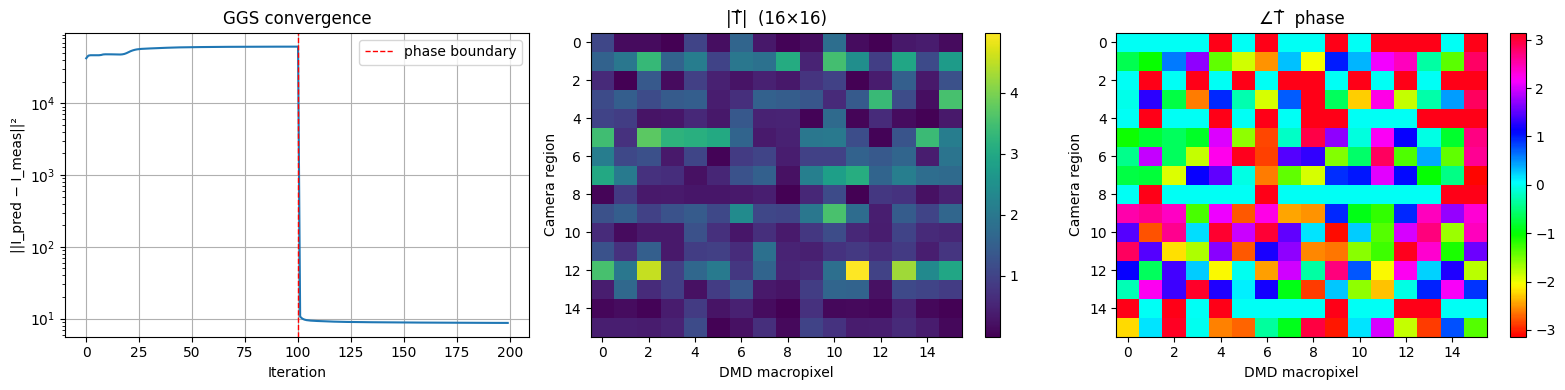

TM     : (16, 16)  dtype=complex64
In-sample Pearson r = 0.216  (should be > 0.8 with enough probes)
MSE   = 4.016368e+04
TM     : (16, 16)  dtype=complex64
In-sample Pearson r = 0.216  (should be > 0.8 with enough probes)


In [57]:
N_ITER = 200

# Quick signal check before running
print(f"Y  — mean: {Y.mean():.2f}   max: {Y.max():.2f}   "
      f"near-zero rows: {(Y.max(axis=1) < 1).sum()}/{len(Y)}")
if Y.mean() < 1:
    print("  ⚠  Signal too low — re-run cell08/ROI preview and adjust CAM_ORIGIN_X/Y.")
else:
    print(f"GGS DMD  ({N_MODES_OUT}×{N_BLOCKS},  K={N_PATTERNS} = {N_PATTERNS//N_BLOCKS}·N) ...")
    TM, tm_bias, residuals = ggs_dmd(X.astype(np.float32), Y, n_iter=N_ITER)

    # ── Convergence ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].semilogy(residuals)
    axes[0].axvline(N_ITER//2, color='r', lw=1, ls='--', label='phase boundary')
    axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("||I_pred − I_meas||²")
    axes[0].set_title("GGS convergence"); axes[0].legend(); axes[0].grid(True)

    im0 = axes[1].imshow(np.abs(TM), cmap='viridis', aspect='auto')
    axes[1].set_title(f"|T̂|  ({TM.shape[0]}×{TM.shape[1]})")
    axes[1].set_xlabel("DMD macropixel"); axes[1].set_ylabel("Camera region")
    plt.colorbar(im0, ax=axes[1])

    im1 = axes[2].imshow(np.angle(TM), cmap='hsv', aspect='auto', vmin=-np.pi, vmax=np.pi)
    axes[2].set_title("∠T̂  phase")
    axes[2].set_xlabel("DMD macropixel"); axes[2].set_ylabel("Camera region")
    plt.colorbar(im1, ax=axes[2])
    plt.tight_layout(); plt.show()


    # ── In-sample fit quality ─────────────────────────────────
    Y_fit = np.abs((X.astype(np.float32) @ np.abs(TM).T))**2
    r_insample = float(np.corrcoef(Y_fit.ravel(), Y.ravel())[0, 1])

        # ── In-sample fit quality ─────────────────────────────────
    Y_fit = np.abs((X.astype(np.float32) @ np.abs(TM).T))**2

    # Pearson correlation
    r_insample = float(np.corrcoef(Y_fit.ravel(), Y.ravel())[0, 1])

    # Mean Squared Error (MSE)
    mse = np.mean((Y_fit - Y) ** 2)
    print(f"TM     : {TM.shape}  dtype={TM.dtype}")
    print(f"In-sample Pearson r = {r_insample:.3f}  (should be > 0.8 with enough probes)")
    print(f"MSE   = {mse:.6e}")
    print(f"TM     : {TM.shape}  dtype={TM.dtype}")
    print(f"In-sample Pearson r = {r_insample:.3f}  (should be > 0.8 with enough probes)")

## 11. Gradient Descent Refinement

Gradient descent refinement  (300 Adam steps) ...


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 3062.58it/s]


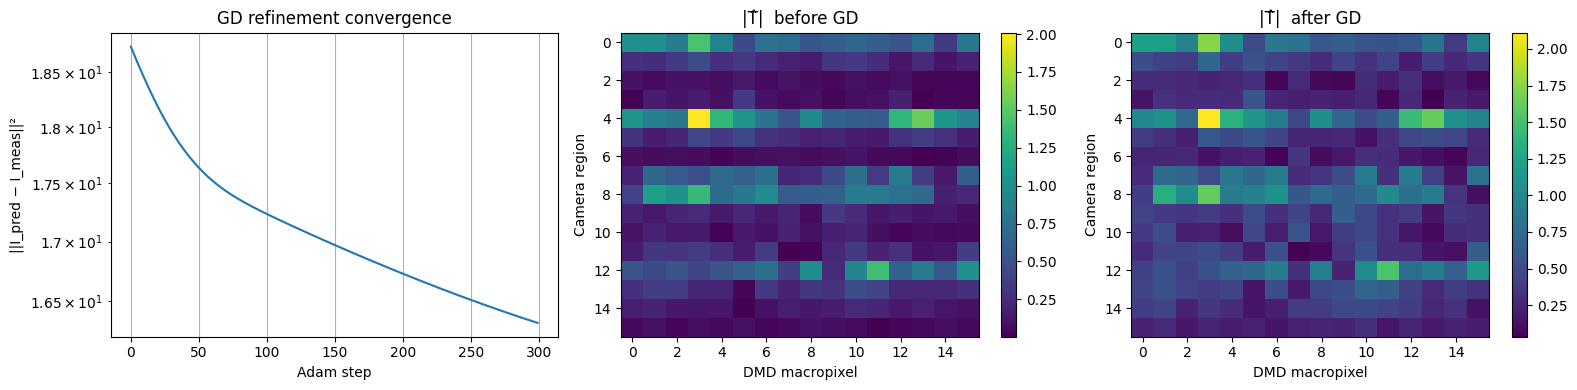

In-sample r  before GD : 0.251
In-sample r  after  GD : 0.233
TM updated to GD-refined version.


In [ ]:
def gd_refine_tm(X, Y, T_init, bias_init, n_steps=300, lr=1e-3,
                 beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Adam gradient descent on intensity residual L = ||  |X·T|²  −  Y  ||².

    Uses Wirtinger gradient: ∂L/∂T_aug* = X_aug.T @ ((I_pred − Y) · Y_pred)
    Wirtinger update rule: T_aug -= lr * grad  (same sign as real GD)

    X       : (K, N)  binary patterns  float32
    Y       : (K, M)  measured intensities  float32
    T_init  : (M, N)  complex TM from GGS
    bias_init: (M,)   complex bias from GGS
    """
    K = len(X)
    T_aug  = np.vstack([T_init.T, bias_init[np.newaxis, :]]).astype(np.complex64)  # (N+1, M)
    X_aug  = np.hstack([X, np.ones((K, 1))]).astype(np.float32)                    # (K, N+1)
    Y_f    = Y.astype(np.float32)

    # Adam state
    m  = np.zeros_like(T_aug)
    v  = np.zeros_like(T_aug, dtype=np.float32)
    residuals = []

    for step in tqdm(range(1, n_steps + 1)):
        Y_pred = X_aug @ T_aug                              # (K, M) complex
        I_pred = np.abs(Y_pred) ** 2                       # (K, M) real
        R      = (I_pred - Y_f).astype(np.complex64)       # (K, M)

        # Wirtinger gradient w.r.t. T_aug*
        grad = (2.0 / Y_f.size) * (X_aug.T @ (R * Y_pred))  # (N+1, M) complex

        # Adam update
        m  = beta1 * m  + (1 - beta1) * grad
        v  = beta2 * v  + (1 - beta2) * np.abs(grad) ** 2
        m_hat = m  / (1 - beta1 ** step)
        v_hat = v  / (1 - beta2 ** step)
        T_aug -= lr * m_hat / (np.sqrt(v_hat) + eps)

        residuals.append(float(np.mean(np.abs(R) ** 2)))

    T_new    = T_aug[:-1].T   # (M, N)
    bias_new = T_aug[-1]      # (M,)
    return T_new, bias_new, residuals


GD_STEPS = 300
GD_LR    = 1e-3

print(f"Gradient descent refinement  ({GD_STEPS} Adam steps) ...")
TM_gd, tm_bias_gd, gd_residuals = gd_refine_tm(
    X.astype(np.float32), Y, TM, tm_bias,
    n_steps=GD_STEPS, lr=GD_LR)

# ── Compare before / after ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].semilogy(gd_residuals)
axes[0].set_xlabel("Adam step"); axes[0].set_ylabel("||I_pred − I_meas||²")
axes[0].set_title("GD refinement convergence"); axes[0].grid(True)

im0 = axes[1].imshow(np.abs(TM),    cmap='viridis', aspect='auto')
axes[1].set_title("|T̂|  before GD"); plt.colorbar(im0, ax=axes[1])
im1 = axes[2].imshow(np.abs(TM_gd), cmap='viridis', aspect='auto')
axes[2].set_title("|T̂|  after GD");  plt.colorbar(im1, ax=axes[2])
for ax in axes[1:]: ax.set_xlabel("DMD macropixel"); ax.set_ylabel("Camera region")
plt.tight_layout(); plt.show()

# In-sample correlation before vs after
def insample_r(T, X, Y):
    I_fit = np.abs(X.astype(np.float32) @ np.abs(T).T) ** 2
    return float(np.corrcoef(I_fit.ravel(), Y.ravel())[0, 1])

r_before = insample_r(TM,    X, Y)
r_after  = insample_r(TM_gd, X, Y)
print(f"In-sample r  before GD : {r_before:.3f}")
print(f"In-sample r  after  GD : {r_after:.3f}")

# Use the refined TM for everything downstream
TM = TM_gd
tm_bias = tm_bias_gd
print("TM updated to GD-refined version.")

## 12. Correlation Check — Does the TM Predict Camera Response?

Send fresh random **binary macropixel** patterns, predict the camera response from the TM,  
then measure the actual response. Reports global Pearson r, per-region r, and per-pattern r.

In [ ]:
def tm_correlation_check(TM_in, dmd_ctrl, cam_ctrl, n_test=20,
                          frame_ms=150, linear_model=True):
    """
    Validate the retrieved TM with fresh binary macropixel probes.
    linear_model=True  → predicted intensity = TM_in @ x      (use for TM_int)
    linear_model=False → predicted intensity = |TM_in|² @ x   (use for complex TM)
    """
    M_eff = np.asarray(TM_in, dtype=np.float32) if linear_model \
            else (np.abs(TM_in)**2).astype(np.float32)

    X_test = np.random.randint(0, 2, (n_test, N_BLOCKS)).astype(np.float32)
    I_pred = (M_eff @ X_test.T).T   # (n_test, N_MODES_OUT)
    I_meas = np.empty_like(I_pred)

    for k in range(n_test):
        pat = dmd_vec_to_pattern(X_test[k].astype(np.uint8), DMD_GRID)
        send_pattern_to_dmd(dmd_ctrl, pat, frame_time_ms=frame_ms, quiet=True)
        time.sleep(0.05)
        img = capture_image(cam_ctrl)
        I_meas[k] = cam_image_to_vec(img, CAM_GRID,
                                     CAM_ORIGIN_X, CAM_ORIGIN_Y,
                                     CAM_REGION_W, CAM_REGION_H)
        print(f"\r  test {k+1}/{n_test}", end='', flush=True)
    print()

    def zscore(a, axis):
        return (a - a.mean(axis=axis, keepdims=True)) / (a.std(axis=axis, keepdims=True) + 1e-9)

    r_per_region  = (zscore(I_pred, 0) * zscore(I_meas, 0)).mean(axis=0)
    r_per_pattern = (zscore(I_pred, 1) * zscore(I_meas, 1)).mean(axis=1)
    global_r = float(np.corrcoef(I_pred.ravel(), I_meas.ravel())[0, 1])

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].scatter(I_pred.ravel(), I_meas.ravel(), s=6, alpha=0.4)
    ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Measured")
    ax[0].set_title(f"Global Pearson r = {global_r:.3f}")
    ax[1].bar(range(N_MODES_OUT), r_per_region); ax[1].set_ylim(-0.2, 1.05)
    ax[1].axhline(0, color='k', lw=0.5)
    ax[1].set_title("Per-camera-region correlation"); ax[1].set_xlabel("region")
    ax[2].bar(range(n_test), r_per_pattern); ax[2].set_ylim(-0.2, 1.05)
    ax[2].axhline(0, color='k', lw=0.5)
    ax[2].set_title("Per-pattern correlation"); ax[2].set_xlabel("test pattern")
    plt.tight_layout(); plt.show()

    print(f"Global r   : {global_r:.3f}")
    print(f"Region r   : mean={r_per_region.mean():.3f}  min={r_per_region.min():.3f}  max={r_per_region.max():.3f}")
    print(f"Pattern r  : mean={r_per_pattern.mean():.3f}")
    return dict(global_r=global_r, r_per_region=r_per_region,
                r_per_pattern=r_per_pattern, I_pred=I_pred, I_meas=I_meas)

  test 20/20


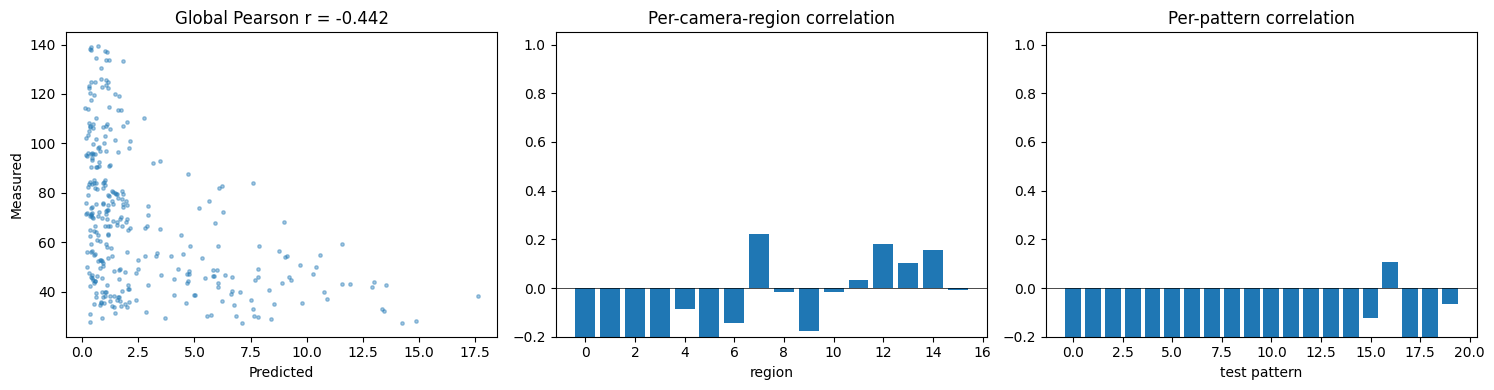

Global r   : -0.442
Region r   : mean=-0.107  min=-0.489  max=0.223
Pattern r  : mean=-0.546


In [ ]:
scores = tm_correlation_check(
    TM, dmd, cam, n_test=20,
    frame_ms=PROBE_FRAME_MS, linear_model=False)

## 13. GS Focusing — Find Binary DMD Pattern to Focus Light

Standard GS between two planes:

| Plane | Constraint |
|---|---|
| **Output (camera)** | Replace amplitude with √(target intensity), keep sign/phase |
| **Input (DMD)** | **Binarise** at median → each macropixel 0 or 1 |

The binarisation step enforces the physical DMD constraint at every iteration.

In [ ]:
def gerchberg_saxton_binary_dmd(TM, target_intensity, n_iter=150, verbose=True):
    """
    GS to find the binary DMD macropixel pattern that produces target_intensity
    at the camera, using the retrieved transmission matrix.

    Binary DMD constraint applied at every iteration:
      x = (x_back >= median(x_back)).astype(uint8)   ← 0 or 1 per macropixel

    The returned best_pattern is a binary vector (0/1);
    use dmd_vec_to_pattern() to expand it to a uint8 (0/255) DMD image.

    TM               : (M, N) complex or real
    target_intensity : (M,)   desired camera intensities
    """
    M, N       = TM.shape
    target_amp = np.sqrt(np.clip(target_intensity, 0, None)).astype(np.float64)
    t_norm     = np.linalg.norm(target_amp) + 1e-12
    TM_adj     = TM.conj().T   # (N, M) adjoint

    x = np.random.randint(0, 2, N).astype(np.float64)   # initial binary guess
    best_x, best_metric = x.copy(), -np.inf
    history = []

    for _ in range(n_iter):
        # Forward
        y = TM @ x                                        # (M,)

        # Output constraint (GS)
        phase = y / (np.abs(y) + 1e-12)
        y_constrained = target_amp * phase                # (M,)

        # Back-project via adjoint
        x_back = np.real(TM_adj @ y_constrained)          # (N,) real

        # *** Binary DMD constraint: threshold at median ***
        x = (x_back >= np.median(x_back)).astype(np.float64)   # 0 or 1

        # Metric: normalised overlap with target
        y_new  = TM @ x
        metric = float(np.real(np.dot(np.abs(y_new), target_amp))
                       / (np.linalg.norm(np.abs(y_new)) * t_norm))
        history.append(metric)

        if metric > best_metric:
            best_metric = metric
            best_x      = x.copy()

    if verbose:
        print(f"GS focusing done | best metric = {best_metric:.4f}  "
              f"(iter {int(np.argmax(history))+1}/{n_iter})")
        print(f"Binary pattern   : {int(best_x.sum())}/{N} macropixels ON  "
              f"(values are 0 or 1 — sent as 0/255 to DMD)")

    return best_x.astype(np.uint8), history

## 14. Focusing Demo — Maximise Intensity on a Target Camera Region

Target: camera region 8  (row 2, col 0)
GS focusing done | best metric = 0.5312  (iter 1/300)
Binary pattern   : 8/16 macropixels ON  (values are 0 or 1 — sent as 0/255 to DMD)


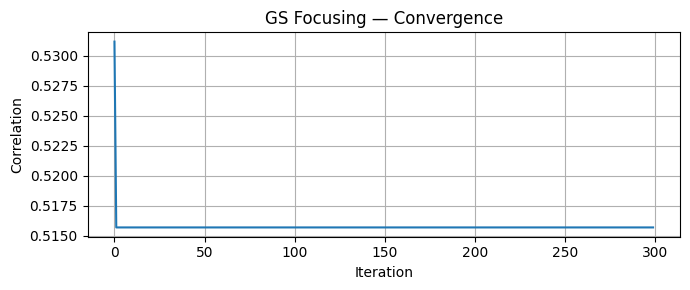

In [ ]:
TARGET_REGION = N_MODES_OUT // 2   # change to any index 0 … N_MODES_OUT-1

target_vec = np.zeros(N_MODES_OUT, dtype=np.float32)
target_vec[TARGET_REGION] = 1.0

print(f"Target: camera region {TARGET_REGION}  "
      f"(row {TARGET_REGION // CAM_GRID[1]}, col {TARGET_REGION % CAM_GRID[1]})")

optimal_dmd_vec, gs_focus_history = gerchberg_saxton_binary_dmd(
    TM, target_vec, n_iter=300)

plt.figure(figsize=(7, 3))
plt.plot(gs_focus_history)
plt.xlabel("Iteration"); plt.ylabel("Correlation")
plt.title("GS Focusing — Convergence"); plt.grid(True)
plt.tight_layout(); plt.show()

DMD sequence running.
DMD sequence running.


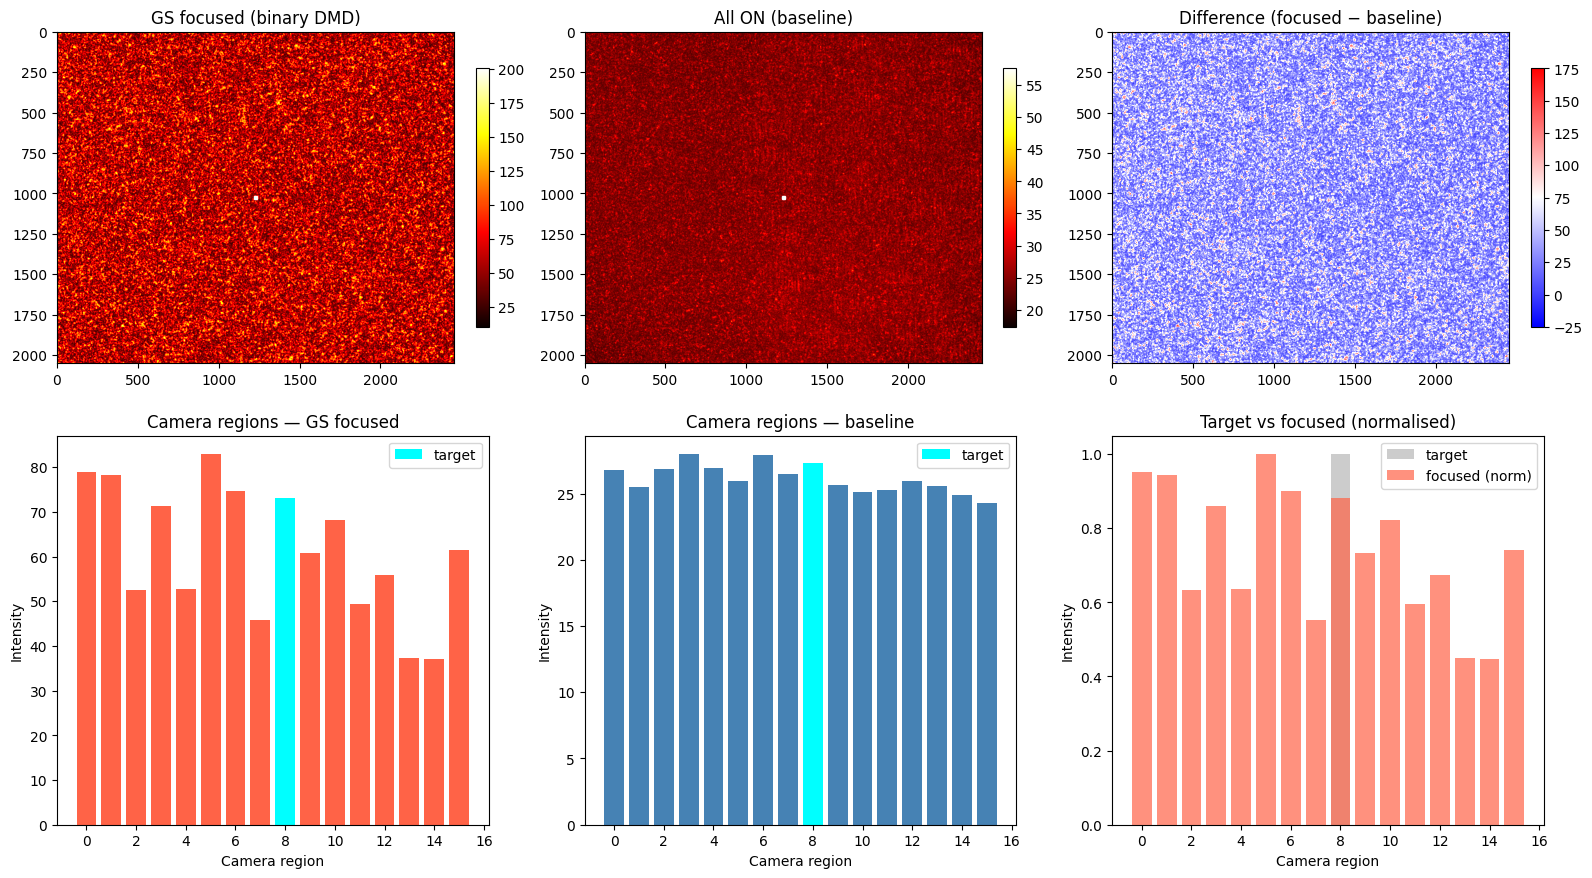

Region 8 — focused: 73.2  baseline: 27.3  enhancement: 2.68×


In [ ]:
optimal_dmd_pat = dmd_vec_to_pattern(optimal_dmd_vec, DMD_GRID)
assert set(np.unique(optimal_dmd_pat).tolist()).issubset({0, 255})

send_pattern_to_dmd(dmd, optimal_dmd_pat, frame_time_ms=500)
time.sleep(0.15)
focused_img = capture_image(cam)
focused_vec = cam_image_to_vec(focused_img, CAM_GRID,
                                CAM_ORIGIN_X, CAM_ORIGIN_Y, CAM_REGION_W, CAM_REGION_H)

all_on_pat = np.full((DMD_HEIGHT, DMD_WIDTH), 255, dtype=np.uint8)
send_pattern_to_dmd(dmd, all_on_pat, frame_time_ms=500)
time.sleep(0.15)
baseline_img = capture_image(cam)
baseline_vec = cam_image_to_vec(baseline_img, CAM_GRID,
                                 CAM_ORIGIN_X, CAM_ORIGIN_Y, CAM_REGION_W, CAM_REGION_H)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img, title in zip(axes[0],
                           [focused_img, baseline_img, focused_img - baseline_img],
                           ["GS focused (binary DMD)", "All ON (baseline)",
                            "Difference (focused − baseline)"]):
    im = ax.imshow(img, cmap='bwr' if 'Diff' in title else 'hot')
    for i in range(CAM_GRID[0]):
        for j in range(CAM_GRID[1]):
            rx = CAM_ORIGIN_X + j * CAM_REGION_W
            ry = CAM_ORIGIN_Y + i * CAM_REGION_H
            col = 'cyan' if i * CAM_GRID[1] + j == TARGET_REGION else 'white'
            ax.add_patch(mpatches.Rectangle(
                (rx, ry), CAM_REGION_W, CAM_REGION_H, lw=1, edgecolor=col, facecolor='none'))
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.03)

x_idx = np.arange(N_MODES_OUT)
axes[1][0].bar(x_idx, focused_vec,  color='tomato')
axes[1][0].bar(TARGET_REGION, focused_vec[TARGET_REGION], color='cyan', label='target')
axes[1][0].set_title("Camera regions — GS focused"); axes[1][0].legend()

axes[1][1].bar(x_idx, baseline_vec, color='steelblue')
axes[1][1].bar(TARGET_REGION, baseline_vec[TARGET_REGION], color='cyan', label='target')
axes[1][1].set_title("Camera regions — baseline"); axes[1][1].legend()

axes[1][2].bar(x_idx, target_vec, color='gray', alpha=0.4, label='target')
axes[1][2].bar(x_idx, focused_vec / (focused_vec.max() + 1e-9),
               color='tomato', alpha=0.7, label='focused (norm)')
axes[1][2].set_title("Target vs focused (normalised)"); axes[1][2].legend()

for ax in axes[1]:
    ax.set_xlabel("Camera region"); ax.set_ylabel("Intensity")
plt.tight_layout(); plt.show()

enh = focused_vec[TARGET_REGION] / (baseline_vec[TARGET_REGION] + 1e-6)
print(f"Region {TARGET_REGION} — focused: {focused_vec[TARGET_REGION]:.1f}  "
      f"baseline: {baseline_vec[TARGET_REGION]:.1f}  enhancement: {enh:.2f}×")

## 15. Optional: Focus onto Multiple Camera Regions Simultaneously

GS focusing done | best metric = 0.3871  (iter 1/300)
Binary pattern   : 8/16 macropixels ON  (values are 0 or 1 — sent as 0/255 to DMD)
DMD sequence running.


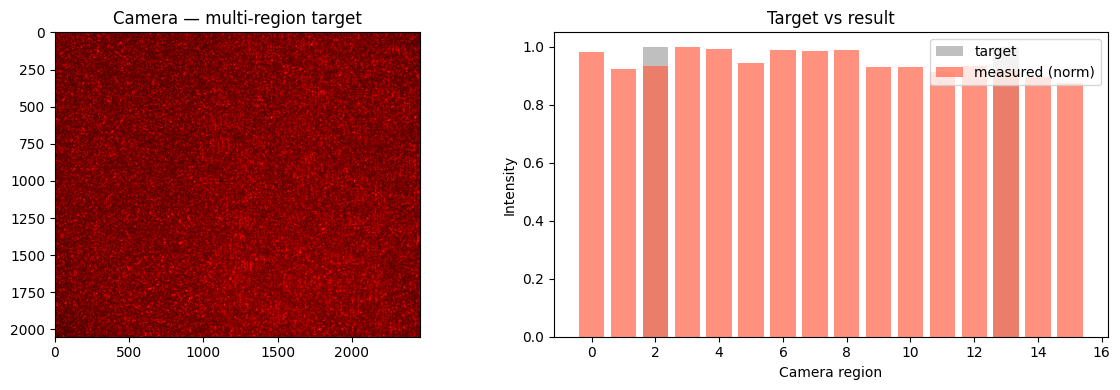

In [ ]:
target_multi = np.zeros(N_MODES_OUT, dtype=np.float32)
target_multi[2]             = 1.0
target_multi[N_MODES_OUT-3] = 1.0

opt_vec_m, _ = gerchberg_saxton_binary_dmd(TM, target_multi, n_iter=300)

opt_pat_m = dmd_vec_to_pattern(opt_vec_m, DMD_GRID)
send_pattern_to_dmd(dmd, opt_pat_m, frame_time_ms=500)
time.sleep(0.15)
result_img = capture_image(cam)
result_vec = cam_image_to_vec(result_img, CAM_GRID,
                               CAM_ORIGIN_X, CAM_ORIGIN_Y, CAM_REGION_W, CAM_REGION_H)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(result_img, cmap='hot')
axes[0].set_title("Camera — multi-region target")
axes[1].bar(np.arange(N_MODES_OUT), target_multi, color='gray', alpha=0.5, label='target')
axes[1].bar(np.arange(N_MODES_OUT), result_vec / (result_vec.max() + 1e-9),
            color='tomato', alpha=0.7, label='measured (norm)')
axes[1].set_xlabel("Camera region"); axes[1].set_ylabel("Intensity")
axes[1].set_title("Target vs result"); axes[1].legend()
plt.tight_layout(); plt.show()

## 16. Cleanup

In [58]:
cam.disconnect()
dmd.stop()

Camera disconnected.
DMD sequence stopped.
